## Step 1: Preamble & Importing Libraries

In [1]:
# Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


## Step 2: Load & Prepare Data


In [2]:
vix = pd.read_csv("VIX.csv")
vix.info()

<class 'pandas.DataFrame'>
RangeIndex: 3725 entries, 0 to 3724
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    3725 non-null   str    
 1   Open    3725 non-null   float64
 2   High    3725 non-null   float64
 3   Low     3725 non-null   float64
 4   Close   3725 non-null   float64
dtypes: float64(4), str(1)
memory usage: 145.6 KB


In [3]:
# Ensure Date is datetime and sort
vix["Date"] = pd.to_datetime(vix["Date"])
vix = vix.sort_values("Date").reset_index(drop=True)

# Feature engineering
vix["Return"] = vix["Close"].pct_change()
vix["Volatility10"] = vix["Return"].rolling(window=10).std()

# Drop NaNs
vix = vix.dropna().reset_index(drop=True)

# Select features
features = ["Open", "High", "Low", "Close", "Return", "Volatility10"]
data = vix[features].values

print("Feature matrix shape:", data.shape)

Feature matrix shape: (3715, 6)


## Step 3: Train / Validation / Test Split

In [4]:
train_size = int(len(data) * 0.70)
val_size = int(len(data) * 0.15)

train_data = data[:train_size]
val_data = data[train_size:train_size + val_size]
test_data = data[train_size + val_size:]

print(train_data.shape, val_data.shape, test_data.shape)

(2600, 6) (557, 6) (558, 6)


## Step 4: Scaling

In [5]:
# Creating a MinMaxScaler and applying it to all sets 3 newaly created sets

scaler = MinMaxScaler(feature_range=(0, 1))

train_scaled = scaler.fit_transform(train_data)
val_scaled = scaler.transform(val_data)
test_scaled = scaler.transform(test_data)

## Step 5: Sequence Generation

In [6]:
# Creating an object to more easily manipulate target model predictor
target_col = "Open"

target_idx = features.index(target_col)

# Create an object for sequences of timesteps

timesteps = 30 # Can more easily be changed to 30, 60, 90, etc based on testing methods/desires

def create_sequences(data, timesteps):
    X, y = [], []
    for i in range(timesteps, len(data)):
        X.append(data[i - timesteps:i])
        y.append(data[i, target_idx])  # index 3 = Close # index 0 = Open
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_scaled, timesteps)
X_val, y_val = create_sequences(val_scaled, timesteps)
X_test, y_test = create_sequences(test_scaled, timesteps)

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(2570, 30, 6) (2570,)
(527, 30, 6) (527,)
(528, 30, 6) (528,)


## Step 6: Build an LSTM Model

In [7]:
lstm_model = Sequential()

# First LSTM layer
lstm_model.add(LSTM(units=100, return_sequences=True,
                    input_shape=(timesteps, X_train.shape[2])))
lstm_model.add(Dropout(0.1))

# Second LSTM layer 
    #removing this layer to make the model 2-layers / to keep things smoother code-wise
#lstm_model.add(LSTM(units=50, return_sequences=True))
#lstm_model.add(Dropout(0.2))

# Third LSTM layer 
    #removing this layer to make the model 3-layers / to keep things smoother code-wise
#lstm_model.add(LSTM(units=50, return_sequences=True))
#lstm_model.add(Dropout(0.2))

# Fourth (final) LSTM layer
lstm_model.add(LSTM(units=100, return_sequences=False))
lstm_model.add(Dropout(0.1))

# Output layer
lstm_model.add(Dense(1))

lstm_model.summary()

/Users/j_farris/miniforge3/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 100)        │        42,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100)            │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 123,301 (481.64 KB)

 Trainable params: 123,301 (481.64 KB)

 Non-trainable params: 0 (0.00 B)

## Step 7: Compile & Train

In [8]:
lstm_model.compile(
    optimizer="adam",
    loss="mean_squared_error",
    metrics=[tf.keras.metrics.MeanAbsoluteError(),
             tf.keras.metrics.RootMeanSquaredError()]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

start_time = time.time()

history = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=True
)

training_time = time.time() - start_time
print(f"Training time: {training_time:.2f} seconds")

Epoch 1/100
161/161 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0024 - mean_absolute_error: 0.0307 - root_mean_squared_error: 0.0486 - val_loss: 0.0012 - val_mean_absolute_error: 0.0249 - val_root_mean_squared_error: 0.0353
Epoch 2/100
161/161 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0012 - mean_absolute_error: 0.0219 - root_mean_squared_error: 0.0341 - val_loss: 8.9534e-04 - val_mean_absolute_error: 0.0215 - val_root_mean_squared_error: 0.0299
Epoch 3/100
161/161 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 8.0439e-04 - mean_absolute_error: 0.0184 - root_mean_squared_error: 0.0284 - val_loss: 4.3658e-04 - val_mean_absolute_error: 0.0150 - val_root_mean_squared_error: 0.0209
Epoch 4/100
161/161 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 6.1400e-04 - mean_absolute_error: 0.0160 - root_mean_squared_error: 0.0248 - val_loss: 3.2176e-04 - val_mean_absolute_error: 0.0124 - val_root_mean_squared_error: 0.0179
Epoch 5/100
161/161 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 5.0408e-04 - mean_abso

## Step 8: Predictions & Inverse Transform

In [9]:
pred_scaled = lstm_model.predict(X_test)

# Build dummy matrix for inverse transform
dummy_pred = np.zeros((len(pred_scaled), len(features)))
dummy_pred[:, target_idx] = pred_scaled[:, 0]

predictions = scaler.inverse_transform(dummy_pred)[:, target_idx]

# Real values reconstruction
dummy_real = np.zeros((len(y_test), len(features)))
dummy_real[:, target_idx] = y_test

real = scaler.inverse_transform(dummy_real)[:, target_idx]

# Metrics
mae = mean_absolute_error(real, predictions)
rmse = np.sqrt(mean_squared_error(real, predictions))

print("MAE:", mae)
print("RMSE:", rmse)


17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
MAE: 0.3731093469164757
RMSE: 0.5725178629746936


## Step 9: Plot Real vs Predicted

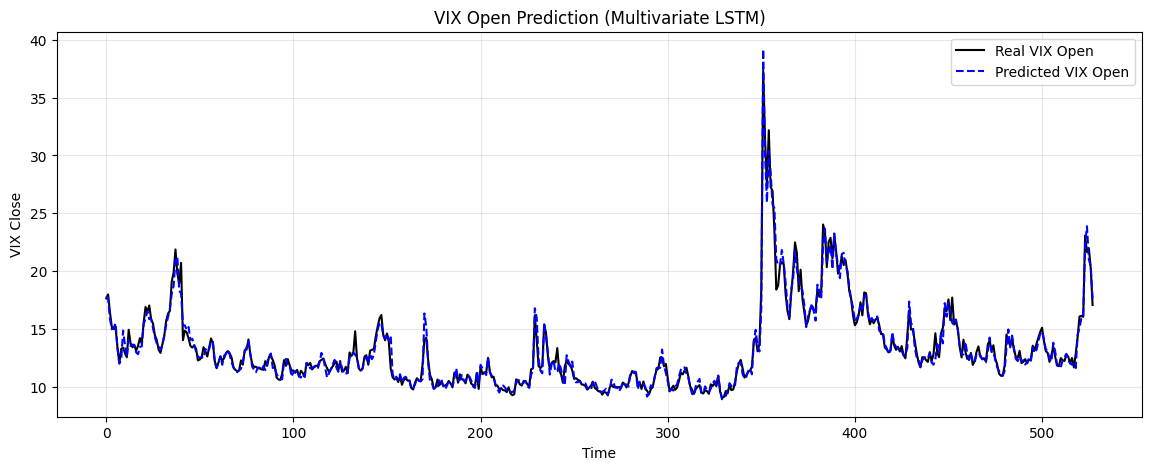

In [12]:
#Plottig real vs predicted values

plt.figure(figsize=(14, 5))
plt.plot(real, label="Real VIX Open", color="black")
plt.plot(predictions, label="Predicted VIX Open", color="blue", linestyle="--")
plt.title("VIX Open Prediction (Multivariate LSTM)")
plt.xlabel("Time")
plt.ylabel("VIX Close")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## Step 10: Plot Training vs Validation Loss

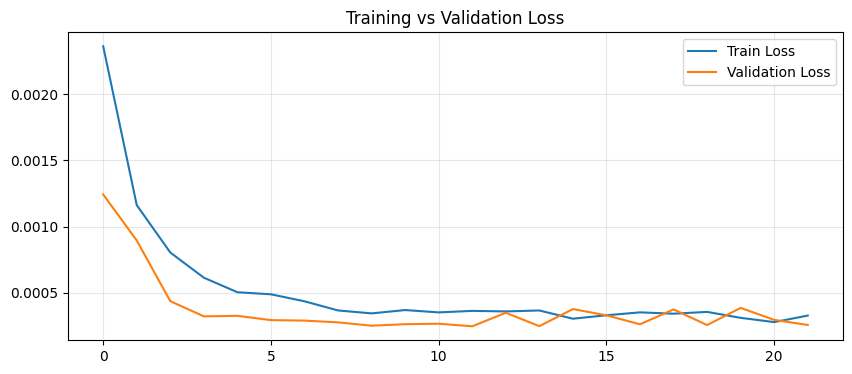

In [11]:
#Plottig training vs validation loss

plt.figure(figsize=(10, 4))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# Grid Search

Trying to connect what we learned in Machine Learning methods with Random Forrests to the possibility of using it for Deep Learning / LSTM model

This takes FOREVER to run, even on Jake's GPU-enabled device, so we only did it once for the options / to better understand instead of looking to hand fine-tune every desired option. I also ran a version with epoch size, which, inclusive of the validation/earlystop coding above resulted in in 100 being the best size).

#### Results:
Firrst run (baseline, one feature): Best params: {'batch_size': 16, 'model_dropout': 0.2, 'model_units': 50}
Best score: 0.9171413126402123

Second run (No Volatility feature) params: {'batch_size': 16, 'model__dropout': 0.2, 'model__num_layers': 2, 'model__units': 100}
Best score: 0.8032985857206176

Thrid run (All features): Best params: {'batch_size': 16, 'model__dropout': 0.1, 'model__num_layers': 2, 'model__units': 100}
Best score: 0.7988751988168885